# 03 — Popularidad, valoración, evolución y KPIs

**Responsable:** Lucas Moncada — Integrante 2  
**Proyecto:** StreamView Analytics — EP1

Este notebook compara Movies y TV Shows mediante las vistas analíticas aprobadas. No vuelve a limpiar los CSV RAW ni reemplaza valores originales. La exploración, limpieza, preparación y función `build_catalog_views` son trabajo previo del integrante 1; Lucas desarrolla únicamente el bloque analítico documentado aquí.

## Criterios de cumplimiento

1. Usar `catalogo_general` y `catalogo_popularity`.
2. Comparar popularidad entre Movies y TV Shows.
3. Separar calidad de valoración (`vote_average`) de cantidad de votos (`vote_count`).
4. Medir y visualizar la asociación popularidad–valoración.
5. Analizar la evolución 2010–2025 por `release_year`.
6. Calcular KPIs reproducibles.
7. Justificar escalas visuales sin modificar el dato original.
8. Cerrar cada análisis con hallazgo, interpretación e implicación.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

working_directory = Path.cwd().resolve()
PROJECT_ROOT = working_directory if (working_directory / 'data' / 'raw').exists() else working_directory.parent
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.business_rules import build_lucas_analysis
from src.data_cleaning import build_catalog_views
from src.visualizations import (
    plot_genre_popularity,
    plot_historical_evolution,
    plot_popularity_comparison,
    plot_popularity_rating_relationship,
    plot_rating_comparison,
    plot_top_popular_contents,
)

views = build_catalog_views(
    DATA_RAW / 'netflix_movies_detailed_up_to_2025.csv',
    DATA_RAW / 'netflix_tv_shows_detailed_up_to_2025.csv',
)
catalogo_general = views['catalogo_general']
catalogo_popularity = views['catalogo_popularity']
catalogo_generos = views['catalogo_generos']
analysis = build_lucas_analysis(catalogo_general, catalogo_popularity, catalogo_generos)

print(f'catalogo_general: {len(catalogo_general):,} entidades')
print(f'catalogo_popularity: {len(catalogo_popularity):,} entidades')
print(f'Conflictos excluidos de popularity: {len(views["popularity_conflict_ids"]):,}')

catalogo_general: 31,991 entidades
catalogo_popularity: 31,982 entidades
Conflictos excluidos de popularity: 9


## Decisiones metodológicas

- `popularity` se analiza solo desde `catalogo_popularity`; así se respetan los nueve conflictos detectados previamente.
- Un título tiene valoración observada cuando `vote_count > 0`. Un `vote_average` igual a cero sin votos no se interpreta como mala calidad.
- La mediana es la medida principal frente a distribuciones muy asimétricas. La media y los cuartiles se conservan como contexto.
- Las escalas logarítmicas se aplican únicamente a los ejes de `popularity` y `vote_count`; las columnas originales no se reemplazan.
- La evolución histórica usa `release_year` para cohortes de estreno y contrasta `date_added.year` como año de incorporación. En esta fuente ambos años coinciden fila por fila, limitación que se demuestra explícitamente.
- Spearman mide asociación monotónica, no causalidad. Se informa por tipo para evitar que diferencias estructurales entre Movies y TV Shows oculten el patrón interno.

In [2]:
scale_diagnostics = []
for variable, source_view in [('popularity', catalogo_popularity), ('vote_count', catalogo_general)]:
    for content_type, values in source_view.groupby('type')[variable]:
        scale_diagnostics.append({
            'variable': variable,
            'type': content_type,
            'asimetria_original': values.skew(),
            'asimetria_log1p': np.log1p(values).skew(),
            'minimo': values.min(),
            'maximo': values.max(),
        })
scale_diagnostics = pd.DataFrame(scale_diagnostics)
display(scale_diagnostics.round(3))

,variable,type,asimetria_original,asimetria_log1p,minimo,maximo
0,popularity,Movie,31.130,1.792,3.860,3876.006
1,popularity,TV Show,16.839,0.857,2.323,6421.923
2,vote_count,Movie,6.662,-0.454,0.000,37119.000
3,vote_count,TV Show,17.869,0.875,0.000,24664.000


## 1. Comparación de popularidad: Movies vs TV Shows

**Audiencia principal:** Gerencia de Marketing y Gerencia de Contenidos.  
**Propósito comunicacional:** mostrar que ambos formatos requieren referencias de popularidad diferenciadas.

La tabla usa la mediana como comparación central y muestra media, cuartiles y máximo para hacer visible la asimetría. Las barras representan la mediana y el intervalo corresponde al rango intercuartílico.

,type,titles,mean_popularity,median_popularity,q1_popularity,q3_popularity,max_popularity
0,Movie,16000,20.385,10.914,7.841,17.336,3876.006
1,TV Show,15982,64.906,36.214,24.910,62.253,6421.923


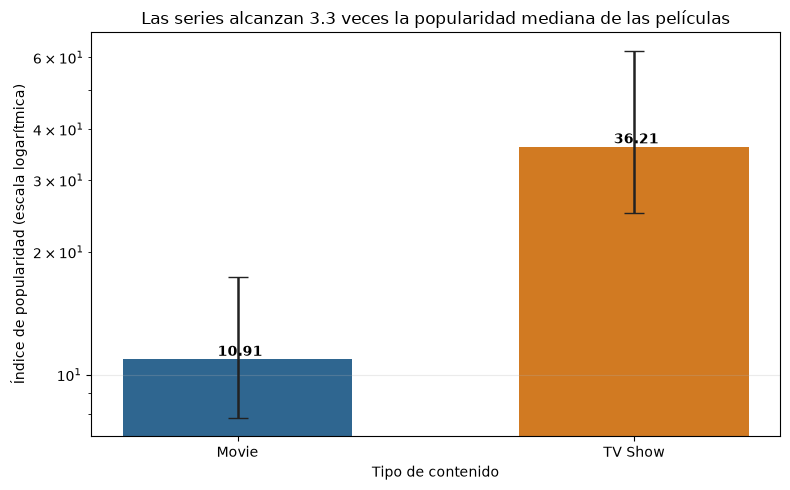

In [3]:
popularity_summary = analysis['popularity_comparison']
display(popularity_summary.round(3))
fig = plot_popularity_comparison(popularity_summary)
fig.savefig(FIGURES_DIR / 'lucas_popularidad_movies_vs_tv.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

In [4]:
pop_by_type = popularity_summary.set_index('type')
movie_pop = pop_by_type.loc['Movie', 'median_popularity']
tv_pop = pop_by_type.loc['TV Show', 'median_popularity']
display(Markdown(f'''### Hallazgo

TV Shows presenta una popularidad mediana de **{tv_pop:.2f}**, frente a **{movie_pop:.2f}** en Movies; equivale a **{tv_pop / movie_pop:.2f} veces** la mediana de películas.

### Interpretación

La diferencia es estructural en esta fuente y no depende solo de máximos extremos. La media es superior a la mediana en ambos grupos, confirmando colas derechas pronunciadas.

### Implicación de negocio

Los resultados sugieren que los umbrales de popularidad utilizados para comparar o priorizar contenidos deberían evaluarse por formato, ya que Movies y TV Shows presentan distribuciones claramente distintas.'''))

### Hallazgo

TV Shows presenta una popularidad mediana de **36.21**, frente a **10.91** en Movies; equivale a **3.32 veces** la mediana de películas.

### Interpretación

La diferencia es estructural en esta fuente y no depende solo de máximos extremos. La media es superior a la mediana en ambos grupos, confirmando colas derechas pronunciadas.

### Implicación de negocio

Los resultados sugieren que los umbrales de popularidad utilizados para comparar o priorizar contenidos deberían evaluarse por formato, ya que Movies y TV Shows presentan distribuciones claramente distintas.

## 2. Rankings explícitos solicitados por el caso

**Audiencia principal:** Gerencia de Marketing, Contenidos y Adquisición.  
**Propósito comunicacional:** identificar contenidos líderes sin confundir popularidad, calificación y cantidad de votos.

Se presentan tres rankings independientes. El Top 10 de calificación exige `vote_count > 0` y usa vote_count para desempatar, pero mantiene el orden literal por `vote_average`.

> **Nota de lectura:** el ranking de calificación es bruto y debe interpretarse junto con `vote_count`; no representa por sí solo un ranking robusto de ‘mejores contenidos’.

### Top 10 por popularity

,rank,title,type,popularity,vote_average,vote_count
0,1,The Late Show with Stephen Colbert,TV Show,6421.923,6.493,288
1,2,The Tonight Show Starring Jimmy Fallon,TV Show,4925.253,5.800,321
2,3,The Gorge,Movie,3876.006,7.785,1572
3,4,Good Mythical Morning,TV Show,3414.466,6.800,67
4,5,Flight Risk,Movie,3320.616,6.000,350
5,6,Chronicles of the Sun,TV Show,2987.485,6.800,117
6,7,Volta por Cima,TV Show,2885.720,5.781,16
7,8,She's the One,TV Show,2862.872,8.100,9
8,9,Mufasa: The Lion King,Movie,2643.627,7.467,1497
9,10,Crazy About You,TV Show,2442.243,5.200,16


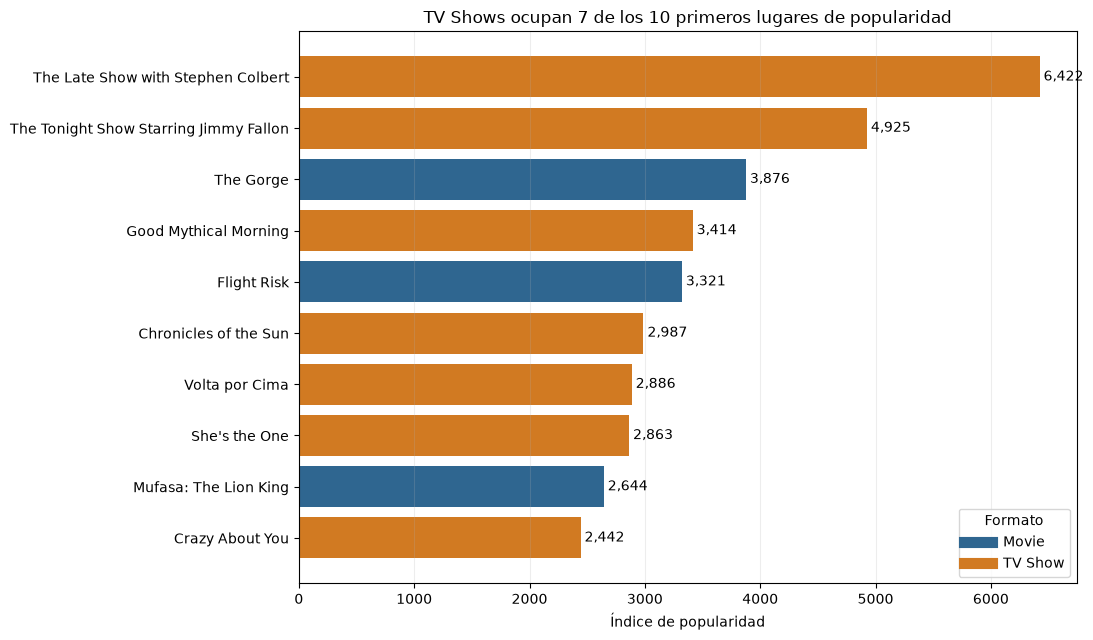

### Top 10 por calificación bruta — interpretar junto con `vote_count`

,rank,title,type,popularity,vote_average,vote_count
0,1,Al Kherbah,TV Show,20.196,10.0,5
1,2,My Crazy Ex,TV Show,41.531,10.0,5
2,3,Slunečná,TV Show,129.064,10.0,5
3,4,Boo! A Call for Adventure,TV Show,26.225,10.0,4
4,5,Five Minutes of Silence,TV Show,30.713,10.0,4
5,6,WWE Raw Top 10,TV Show,6.481,10.0,4
6,7,AI Football GGO,TV Show,74.030,10.0,3
7,8,Balota,Movie,14.678,10.0,3
8,9,Beauties in the Closet,TV Show,70.814,10.0,3
9,10,Chasing in the Wild,TV Show,29.826,10.0,3


### Top 10 por vote_count

,rank,title,type,popularity,vote_average,vote_count
0,1,Inception,Movie,156.242,8.369,37119
1,2,Interstellar,Movie,288.193,8.500,36625
2,3,Deadpool,Movie,106.641,7.622,31371
3,4,The Avengers,Movie,186.111,7.730,31285
4,5,Avengers: Infinity War,Movie,285.584,8.200,30231
5,6,Guardians of the Galaxy,Movie,49.395,7.900,28308
6,7,Django Unchained,Movie,60.467,8.183,26532
7,8,Joker,Movie,83.229,8.100,26169
8,9,Avengers: Endgame,Movie,133.255,8.200,26065
9,10,Game of Thrones,TV Show,812.157,8.500,24664


In [5]:
top_popularity = analysis['top_popularity']
top_rated = analysis['top_rated']
top_voted = analysis['top_voted']
display(Markdown('### Top 10 por popularity'))
display(top_popularity.drop(columns='content_id').round(3))
fig = plot_top_popular_contents(top_popularity)
fig.savefig(FIGURES_DIR / 'lucas_top_10_popularidad.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
display(Markdown('### Top 10 por calificación bruta — interpretar junto con `vote_count`'))
display(top_rated.drop(columns='content_id').round(3))
display(Markdown('### Top 10 por vote_count'))
display(top_voted.drop(columns='content_id').round(3))

In [6]:
popular_type_counts = top_popularity['type'].value_counts()
top_rating_min_votes = int(top_rated['vote_count'].min())
display(Markdown(f'''### Hallazgo

**{top_popularity.iloc[0]['title']}** lidera popularity con {top_popularity.iloc[0]['popularity']:,.0f} puntos. {popular_type_counts.index[0]} ocupa {popular_type_counts.iloc[0]} de los 10 primeros puestos. El Top 10 por vote_count contiene {(top_voted['type'] == 'Movie').sum()} Movies, mientras los títulos con vote_average máximo tienen entre {top_rating_min_votes} y {int(top_rated['vote_count'].max())} votos.

### Interpretación

Los tres rankings responden preguntas distintas. Un puntaje perfecto con pocos votos no posee el mismo respaldo que un título con decenas de miles de votos.

### Implicación de negocio

Los rankings ejecutivos deberían mostrar conjuntamente formato, vote_average y vote_count, evitando presentar un Top 10 de calificación como recomendación definitiva sin un criterio mínimo de evidencia.'''))

### Hallazgo

**The Late Show with Stephen Colbert** lidera popularity con 6,422 puntos. TV Show ocupa 7 de los 10 primeros puestos. El Top 10 por vote_count contiene 9 Movies, mientras los títulos con vote_average máximo tienen entre 3 y 5 votos.

### Interpretación

Los tres rankings responden preguntas distintas. Un puntaje perfecto con pocos votos no posee el mismo respaldo que un título con decenas de miles de votos.

### Implicación de negocio

Los rankings ejecutivos deberían mostrar conjuntamente formato, vote_average y vote_count, evitando presentar un Top 10 de calificación como recomendación definitiva sin un criterio mínimo de evidencia.

## 3. Valoración: calidad y cantidad de votos

**Audiencia principal:** Gerencia de Contenidos y Adquisición.  
**Propósito comunicacional:** distinguir el puntaje observado de la cantidad de evidencia que lo respalda.

`vote_average` expresa el puntaje; `vote_count` expresa cuánta evidencia sostiene ese puntaje. También se informa cobertura porque no todos los títulos tienen votos. La valoración ponderada por votos queda como indicador complementario, no sustituye la mediana por título.

,type,titles,rated_titles,rating_coverage_pct,mean_vote_average,median_vote_average,weighted_vote_average,median_vote_count,total_votes
0,Movie,16000,15106,94.412,6.309,6.4,6.838,154.0,11498498
1,TV Show,15991,12325,77.075,7.024,7.2,7.859,9.0,1712228


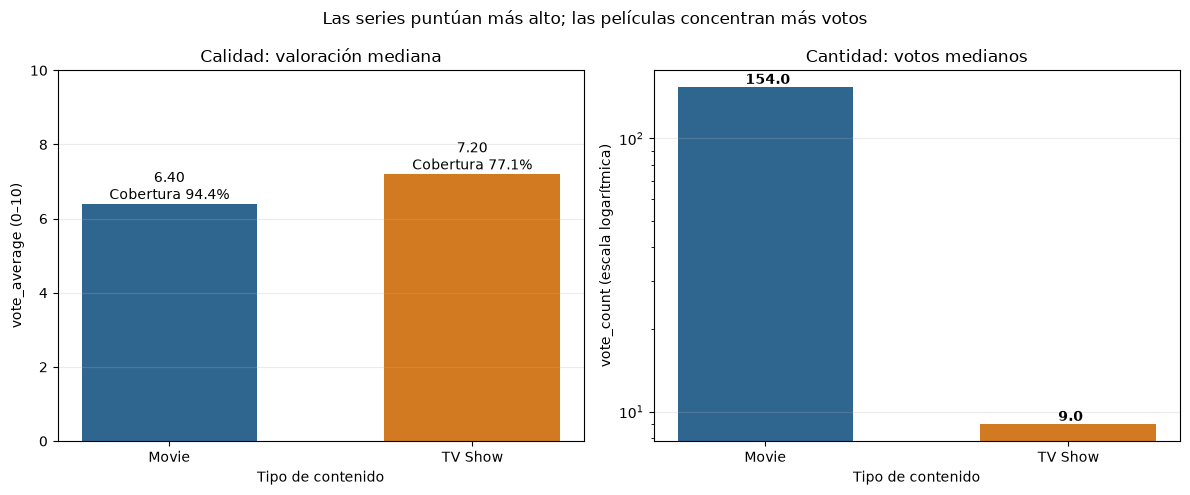

In [7]:
rating_summary = analysis['rating_summary']
display(rating_summary.round(3))
fig = plot_rating_comparison(rating_summary)
fig.savefig(FIGURES_DIR / 'lucas_valoracion_y_votos.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

In [8]:
rating_by_type = rating_summary.set_index('type')
movie_rating = rating_by_type.loc['Movie']
tv_rating = rating_by_type.loc['TV Show']
display(Markdown(f'''### Hallazgo

Entre títulos con votos, TV Shows alcanza una valoración mediana de **{tv_rating['median_vote_average']:.2f}**, superior a **{movie_rating['median_vote_average']:.2f}** en Movies. Sin embargo, Movies tiene **{movie_rating['median_vote_count']:,.0f} votos medianos** y TV Shows solo **{tv_rating['median_vote_count']:,.0f}**. La cobertura es {movie_rating['rating_coverage_pct']:.1f}% y {tv_rating['rating_coverage_pct']:.1f}%, respectivamente.

### Interpretación

Las series muestran mejor puntaje típico, pero sostenido por una cantidad de votos mucho menor y con menor cobertura. Calidad percibida y volumen de evidencia no son equivalentes.

### Implicación de negocio

Los rankings no deberían ordenar solo por vote_average: conviene mostrar también vote_count y aplicar un mínimo de evidencia según el uso del indicador.'''))

### Hallazgo

Entre títulos con votos, TV Shows alcanza una valoración mediana de **7.20**, superior a **6.40** en Movies. Sin embargo, Movies tiene **154 votos medianos** y TV Shows solo **9**. La cobertura es 94.4% y 77.1%, respectivamente.

### Interpretación

Las series muestran mejor puntaje típico, pero sostenido por una cantidad de votos mucho menor y con menor cobertura. Calidad percibida y volumen de evidencia no son equivalentes.

### Implicación de negocio

Los rankings no deberían ordenar solo por vote_average: conviene mostrar también vote_count y aplicar un mínimo de evidencia según el uso del indicador.

## 4. Relación popularidad–calificación

**Audiencia principal:** Gerencia de Contenidos y Gerencia de Marketing.  
**Propósito comunicacional:** evitar que popularity se utilice como sustituto de vote_average.

Se calcula rho de Spearman porque la popularidad es muy asimétrica y no se presupone una relación lineal. Solo entran títulos con `vote_count > 0` y popularidad válida.

,scope,titles,spearman_rho
0,Overall,27430,0.3225
1,Movie,15106,0.2153
2,TV Show,12324,0.0355


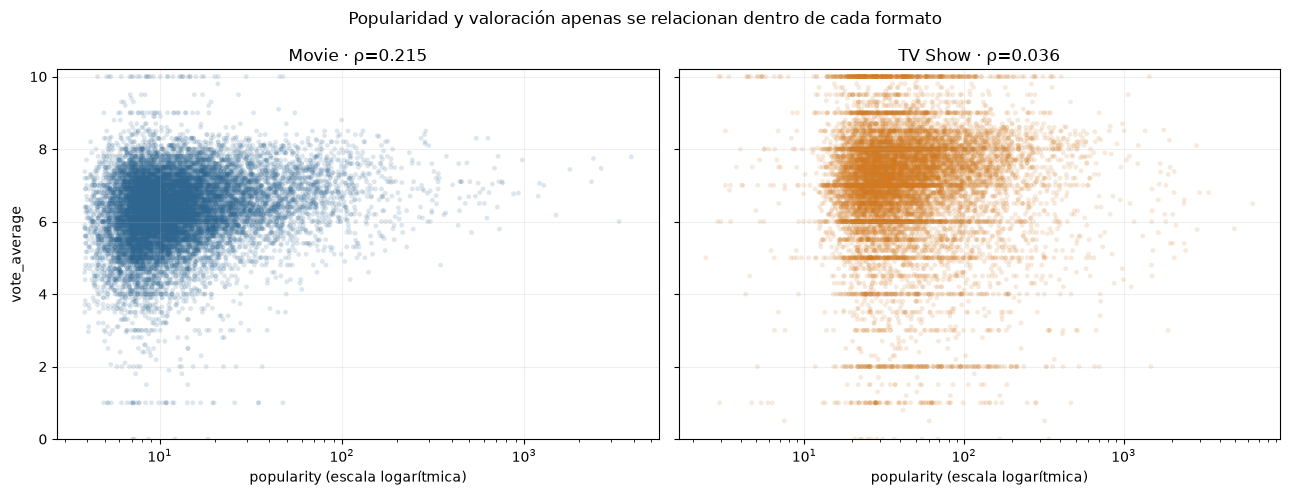

In [9]:
association_summary = analysis['popularity_rating_association']
display(association_summary.round(4))
fig = plot_popularity_rating_relationship(catalogo_popularity, association_summary)
fig.savefig(FIGURES_DIR / 'lucas_popularidad_vs_valoracion.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

In [10]:
rho = association_summary.set_index('scope')['spearman_rho']
display(Markdown(f'''### Hallazgo

La asociación es **débil y positiva en Movies** (ρ={rho['Movie']:.3f}) y **prácticamente nula en TV Shows** (ρ={rho['TV Show']:.3f}). El valor agregado (ρ={rho['Overall']:.3f}) es mayor que los resultados dentro de cada tipo.

### Interpretación

Una mayor popularidad no garantiza una mejor valoración. El coeficiente global está influido por mezclar dos formatos con niveles distintos de popularity y vote_average, por lo que la lectura por tipo es la principal.

### Implicación de negocio

Los resultados respaldan mantener popularidad y valoración como dimensiones separadas del tablero; popularity no debería utilizarse como sustituto directo de vote_average.'''))

### Hallazgo

La asociación es **débil y positiva en Movies** (ρ=0.215) y **prácticamente nula en TV Shows** (ρ=0.036). El valor agregado (ρ=0.322) es mayor que los resultados dentro de cada tipo.

### Interpretación

Una mayor popularidad no garantiza una mejor valoración. El coeficiente global está influido por mezclar dos formatos con niveles distintos de popularity y vote_average, por lo que la lectura por tipo es la principal.

### Implicación de negocio

Los resultados respaldan mantener popularidad y valoración como dimensiones separadas del tablero; popularity no debería utilizarse como sustituto directo de vote_average.

## 5. Popularidad por género

**Audiencia principal:** Gerencia de Contenidos y Adquisición.  
**Propósito comunicacional:** reconocer géneros con mayor popularidad típica sin confundir asociaciones de género con contenidos únicos.

`catalogo_generos` se une con `catalogo_popularity` mediante `content_id`. La métrica principal es la mediana y la tabla conserva promedio y cobertura.

> **Nota visual:** `Unknown` permanece en la tabla analítica completa y se excluye únicamente de este Top 10 gráfico.

,genre,titles,mean_popularity,median_popularity
0,Soap,631,155.458,88.398
1,News,113,102.000,53.556
2,Talk,653,130.786,51.283
3,Kids,835,66.362,40.972
4,Reality,1629,79.371,40.789
5,Action & Adventure,1988,67.400,38.999
6,Sci-Fi & Fantasy,1958,61.434,38.053
7,War & Politics,323,51.893,34.645
9,Animation,4069,45.550,26.937
10,Family,3014,55.567,26.124


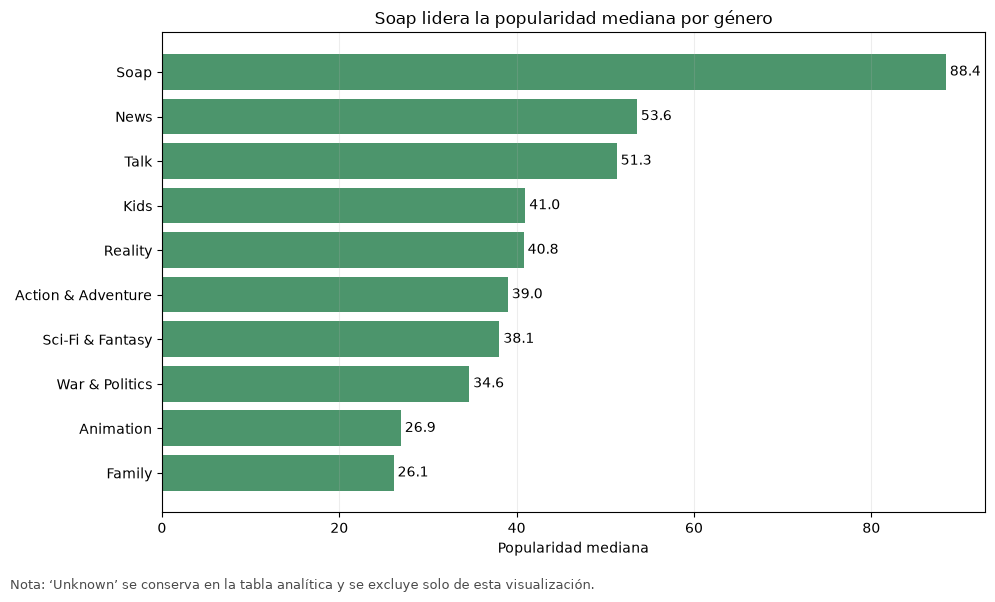

In [11]:
genre_popularity = analysis['popularity_by_genre']
genre_presentable = genre_popularity.loc[genre_popularity['genre'].str.casefold().ne('unknown')].head(10)
display(Markdown("> **Nota visual:** `Unknown` permanece en la tabla analítica completa y se excluye únicamente de este Top 10 gráfico."))
display(genre_presentable.round(3))
fig = plot_genre_popularity(genre_popularity)
fig.savefig(FIGURES_DIR / 'lucas_popularidad_por_genero.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

In [12]:
genre_leader = genre_presentable.iloc[0]
display(Markdown(f'''### Hallazgo

**{genre_leader['genre']}** lidera con popularidad mediana de **{genre_leader['median_popularity']:.2f}** en {int(genre_leader['titles']):,} contenidos asociados.

### Interpretación

El ranking compara la popularidad típica dentro de cada género. Como un contenido puede pertenecer a varios géneros, las filas representan asociaciones y no categorías excluyentes. La etiqueta `Unknown` permanece trazable en la tabla completa, pero se excluye del Top 10 visual porque no representa un género interpretable.

### Implicación de negocio

Los géneros líderes pueden orientar una revisión de oferta y adquisición, pero la decisión debería considerar también volumen de títulos, valoración y objetivos de diversidad del catálogo.'''))

### Hallazgo

**Soap** lidera con popularidad mediana de **88.40** en 631 contenidos asociados.

### Interpretación

El ranking compara la popularidad típica dentro de cada género. Como un contenido puede pertenecer a varios géneros, las filas representan asociaciones y no categorías excluyentes. La etiqueta `Unknown` permanece trazable en la tabla completa, pero se excluye del Top 10 visual porque no representa un género interpretable.

### Implicación de negocio

Los géneros líderes pueden orientar una revisión de oferta y adquisición, pero la decisión debería considerar también volumen de títulos, valoración y objetivos de diversidad del catálogo.

## 6. Evolución histórica 2010–2025

**Audiencia principal:** Gerencia General y Gerencia de Contenidos.  
**Propósito comunicacional:** comparar cohortes anuales y advertir la menor madurez de los estrenos recientes.

La serie usa año de estreno (`release_year`). Se muestran popularidad mediana y valoración mediana entre títulos con votos; la tabla conserva conteos y cobertura para contextualizar 2025.

,release_year,type,titles,popularity_titles,median_popularity,rated_titles,median_vote_average,median_vote_count,rating_coverage_pct
0,2010,Movie,1000,1000,7.682,999,6.200,122.0,99.900
1,2010,TV Show,1000,1000,32.392,685,7.000,6.0,68.500
2,2011,Movie,1000,1000,7.920,999,6.223,141.0,99.900
3,2011,TV Show,1000,1000,36.972,710,7.000,6.0,71.000
4,2012,Movie,1000,1000,8.888,998,6.182,131.0,99.800
5,2012,TV Show,1000,1000,36.201,732,7.000,6.0,73.200
6,2013,Movie,1000,1000,9.354,998,6.240,158.0,99.800
7,2013,TV Show,1000,1000,40.218,725,7.100,7.0,72.500
8,2014,Movie,1000,1000,10.334,998,6.300,192.5,99.800
9,2014,TV Show,1000,1000,36.518,781,7.200,8.0,78.100


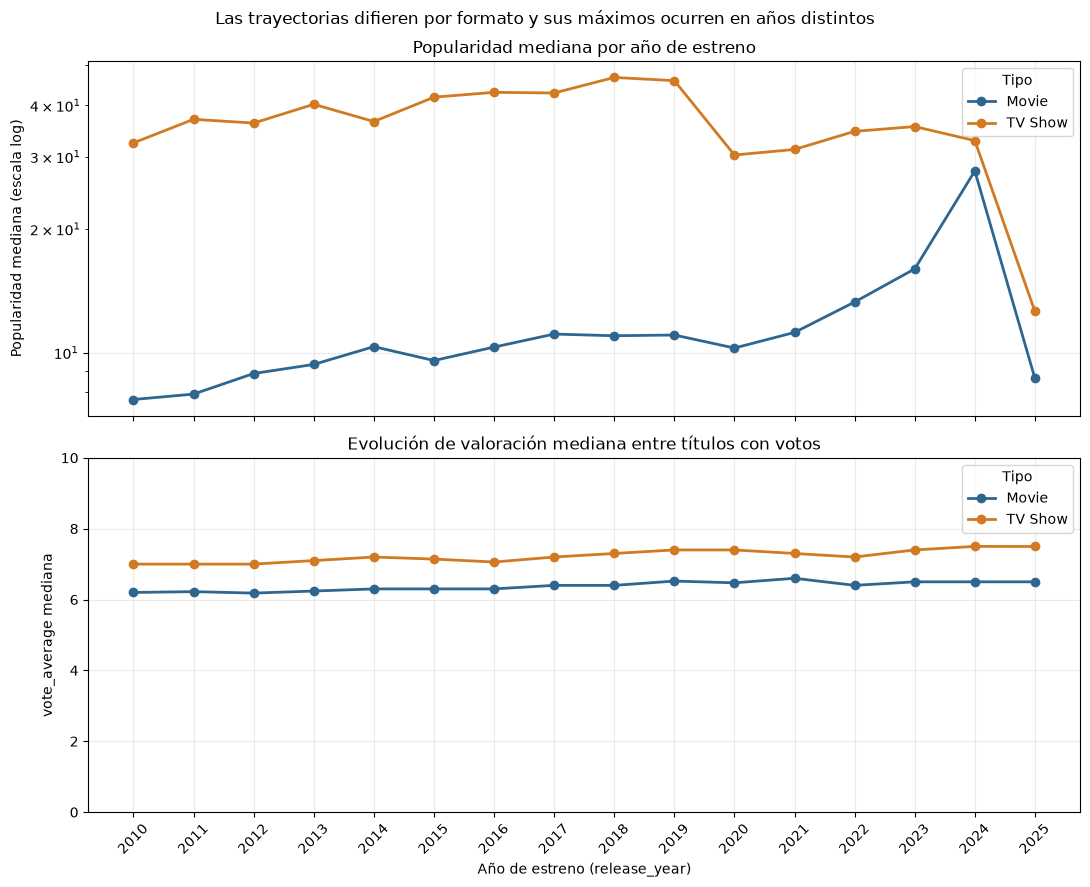

In [13]:
historical = analysis['historical_evolution']
display(historical.round(3))
fig = plot_historical_evolution(historical)
fig.savefig(FIGURES_DIR / 'lucas_evolucion_2010_2025.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

In [14]:
peak_rows = historical.loc[historical.groupby('type')['median_popularity'].idxmax()].set_index('type')
rows_2025 = historical.loc[historical['release_year'] == 2025].set_index('type')
display(Markdown(f'''### Hallazgo

Movies alcanza su mayor popularidad mediana en **{int(peak_rows.loc['Movie', 'release_year'])}** ({peak_rows.loc['Movie', 'median_popularity']:.2f}) y TV Shows en **{int(peak_rows.loc['TV Show', 'release_year'])}** ({peak_rows.loc['TV Show', 'median_popularity']:.2f}). En 2025 la cobertura de valoración cae a {rows_2025.loc['Movie', 'rating_coverage_pct']:.1f}% en Movies y {rows_2025.loc['TV Show', 'rating_coverage_pct']:.1f}% en TV Shows.

### Interpretación

La caída de 2025 debe leerse como cohorte reciente con menos votos acumulados, no automáticamente como deterioro de calidad. Los conteos por año son casi uniformes por construcción de la fuente, por lo que la evolución de medianas aporta más información que el volumen.

### Implicación de negocio

Las comparaciones temporales deberían incluir madurez o cobertura de votos; evaluar estrenos recientes con el mismo estándar histórico produciría conclusiones prematuras.'''))

### Hallazgo

Movies alcanza su mayor popularidad mediana en **2024** (27.68) y TV Shows en **2018** (46.75). En 2025 la cobertura de valoración cae a 26.5% en Movies y 37.1% en TV Shows.

### Interpretación

La caída de 2025 debe leerse como cohorte reciente con menos votos acumulados, no automáticamente como deterioro de calidad. Los conteos por año son casi uniformes por construcción de la fuente, por lo que la evolución de medianas aporta más información que el volumen.

### Implicación de negocio

Las comparaciones temporales deberían incluir madurez o cobertura de votos; evaluar estrenos recientes con el mismo estándar histórico produciría conclusiones prematuras.

### Estrenos vs incorporaciones al catálogo

El caso distingue `release_year` (año de estreno) de `date_added.year` (año de incorporación). Antes de graficarlos como tendencias diferentes se verifica si la fuente contiene realmente esa distinción.

In [15]:
catalog_timeline = analysis['catalog_timeline']
temporal_alignment = analysis['temporal_alignment']
display(temporal_alignment.round(3))
annual_comparison = catalog_timeline.pivot_table(
    index=['year', 'type'], columns='event', values='titles', aggfunc='sum'
).reset_index()
annual_comparison['diferencia'] = annual_comparison['Incorporaciones'] - annual_comparison['Estrenos']
display(annual_comparison.round(3))

,type,titles,same_year_titles,same_year_pct,median_year_gap,min_year_gap,max_year_gap
0,Movie,16000,16000,100.0,0.0,0,0
1,TV Show,15991,15991,100.0,0.0,0,0


event,year,type,Estrenos,Incorporaciones,diferencia
0,2010,Movie,1000,1000,0
1,2010,TV Show,1000,1000,0
2,2011,Movie,1000,1000,0
3,2011,TV Show,1000,1000,0
4,2012,Movie,1000,1000,0
5,2012,TV Show,1000,1000,0
6,2013,Movie,1000,1000,0
7,2013,TV Show,1000,1000,0
8,2014,Movie,1000,1000,0
9,2014,TV Show,1000,1000,0


In [16]:
display(Markdown(f'''### Hallazgo

En Movies y TV Shows, `date_added.year` coincide con `release_year` en **{temporal_alignment['same_year_pct'].min():.1f}%** de las entidades. Las cantidades anuales de estrenos e incorporaciones son idénticas.

### Interpretación

Aunque ambos campos representan conceptos diferentes, esta fuente simulada no conserva un desfase temporal entre estreno e incorporación. Dos líneas en un gráfico quedarían completamente superpuestas y no agregarían información.

### Implicación de negocio

No es posible inferir tendencias independientes de adquisición o velocidad de incorporación con estos datos. El tablero debería comunicar esta limitación y evitar presentar la coincidencia como comportamiento operativo real.'''))

### Hallazgo

En Movies y TV Shows, `date_added.year` coincide con `release_year` en **100.0%** de las entidades. Las cantidades anuales de estrenos e incorporaciones son idénticas.

### Interpretación

Aunque ambos campos representan conceptos diferentes, esta fuente simulada no conserva un desfase temporal entre estreno e incorporación. Dos líneas en un gráfico quedarían completamente superpuestas y no agregarían información.

### Implicación de negocio

No es posible inferir tendencias independientes de adquisición o velocidad de incorporación con estos datos. El tablero debería comunicar esta limitación y evitar presentar la coincidencia como comportamiento operativo real.

## 7. KPIs reproducibles del bloque

Primero se muestran los KPIs ejecutivos principales en una tabla compacta por formato. Después se conserva el catálogo técnico completo con alcance, unidad y definición. Todos los valores se reconstruyen desde las vistas en cada ejecución.

In [17]:
kpis = analysis['kpi_summary']
executive_kpis = (
    kpis.loc[kpis['kpi'].isin([
        'Popularidad promedio',
        'Calificación promedio',
        'Cobertura de valoración',
        'Votos medianos',
    ])]
    .pivot(index='scope', columns='kpi', values='value')
    .reset_index()
)
display(Markdown('### KPIs ejecutivos destacados'))
display(executive_kpis.round(3))
display(Markdown('### Catálogo técnico completo de KPIs'))
display(kpis.round({'value': 4}))

### KPIs ejecutivos destacados

kpi,scope,Calificación promedio,Cobertura de valoración,Popularidad promedio,Votos medianos
0,Movie,6.309,94.412,20.385,154.0
1,TV Show,7.024,77.075,64.906,9.0


### Catálogo técnico completo de KPIs

,kpi,scope,value,unit,definition
0,Popularidad promedio,Movie,20.3847,índice de popularidad,Media en catalogo_popularity; conflictos exclu...
1,Popularidad mediana,Movie,10.9135,índice de popularidad,Mediana en catalogo_popularity; conflictos exc...
2,Popularidad promedio,TV Show,64.9065,índice de popularidad,Media en catalogo_popularity; conflictos exclu...
3,Popularidad mediana,TV Show,36.2140,índice de popularidad,Mediana en catalogo_popularity; conflictos exc...
4,Cobertura de valoración,Movie,94.4125,% de títulos,Títulos con vote_count > 0 sobre catalogo_gene...
5,Calificación promedio,Movie,6.3089,puntos (0–10),Media de vote_average entre títulos con votos.
6,Valoración mediana,Movie,6.4000,puntos (0–10),Mediana de vote_average entre títulos con votos.
7,Votos medianos,Movie,154.0000,votos,Mediana de vote_count entre títulos con votos.
8,Cobertura de valoración,TV Show,77.0746,% de títulos,Títulos con vote_count > 0 sobre catalogo_gene...
9,Calificación promedio,TV Show,7.0237,puntos (0–10),Media de vote_average entre títulos con votos.


## Cierre y cumplimiento

- Todo el bloque se reconstruye desde `catalogo_general`, `catalogo_popularity` y la vista auxiliar preparada `catalogo_generos`.
- Popularidad, valoración, asociación y evolución tienen tabla, visualización y narrativa.
- Los KPIs se calculan en `src/business_rules.py` y no dependen del estado del notebook.
- Las escalas logarítmicas son decisiones visuales; no alteran `popularity` ni `vote_count`.
- Las conclusiones describen el catálogo observado y no implican causalidad, reproducciones reales ni preferencias individuales de audiencia.